# Notebook 1: Housing Dataset
**Fuente:** https://www.kaggle.com/datasets/marcopale/housing

Este notebook cubre la preparación completa del dataset de precios de viviendas, incluyendo EDA, limpieza, preprocesamiento y exportación de conjuntos de entrenamiento y prueba.

## Introducción
El dataset **Housing** contiene información sobre características de viviendas y sus precios de venta. El objetivo típico es predecir el precio de una vivienda en función de sus atributos (regresión supervisada). Las variables incluyen superficie, número de habitaciones, ubicación, antigüedad, entre otras.

## arga del Dataset
Se ofrecen dos opciones: carga desde Google Drive (entorno Colab) y carga desde entorno local. Asegúrate de haber descargado el archivo `housing.csv` desde Kaggle.

In [1]:
import os
import pandas as pd
import numpy as np

# Montar Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Entorno local detectado.')

# Ruta flexible
if IN_COLAB:
    DATA_PATH = '/content/drive/MyDrive/datasets/housing.csv'
    EXPORT_PATH = '/content/drive/MyDrive/datasets/housing/'
else:
    DATA_PATH = 'housing.csv'
    EXPORT_PATH = './housing_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Mounted at /content/drive
Dataset cargado: 2930 filas x 82 columnas


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Identificación del Tipo de Problema
Se analiza la variable objetivo para determinar si se trata de un problema de **regresión** o **clasificación**.

In [9]:
print('Columnas disponibles:')
print(df.columns.tolist())

# Intentar detectar la columna objetivo
posibles_targets = [c for c in df.columns if 'price' in c.lower() or 'value' in c.lower() or 'sale' in c.lower()]
# Explicitly set TARGET to 'SalePrice' as it's the correct numerical target for regression
TARGET = 'SalePrice'
print(f'\nVariable objetivo identificada: {TARGET}')
print(f'Tipo de dato: {df[TARGET].dtype}')
print(f'Valores únicos (muestra): {df[TARGET].nunique()}')
print('\n→ Tipo de problema: REGRESIÓN (variable continua de precio/valor)')

Columnas disponibles:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Pav

##  Análisis Exploratorio (EDA)
Exploramos la distribución de variables, valores nulos, outliers y correlaciones.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print('=== Información general ===')
df.info()
print('\n=== Estadísticas descriptivas ===')
display(df.describe())

=== Información general ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null  

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [4]:
print('=== Valores nulos por columna ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0])
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

=== Valores nulos por columna ===
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Total de valores nulos: 15749


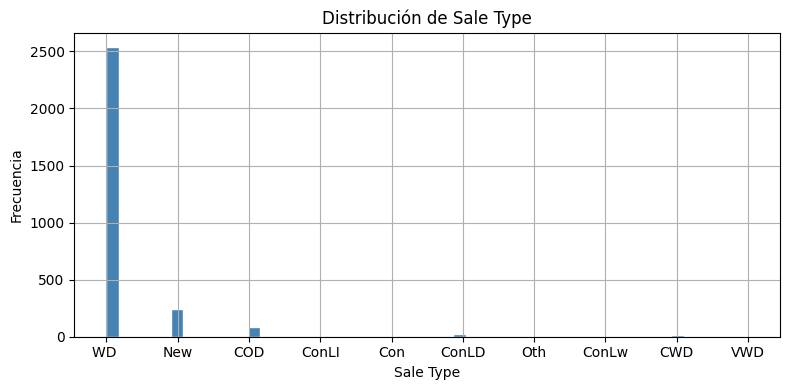

In [5]:
# Distribución de la variable objetivo
plt.figure(figsize=(8, 4))
df[TARGET].hist(bins=50, color='steelblue', edgecolor='white')
plt.title(f'Distribución de {TARGET}')
plt.xlabel(TARGET)
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

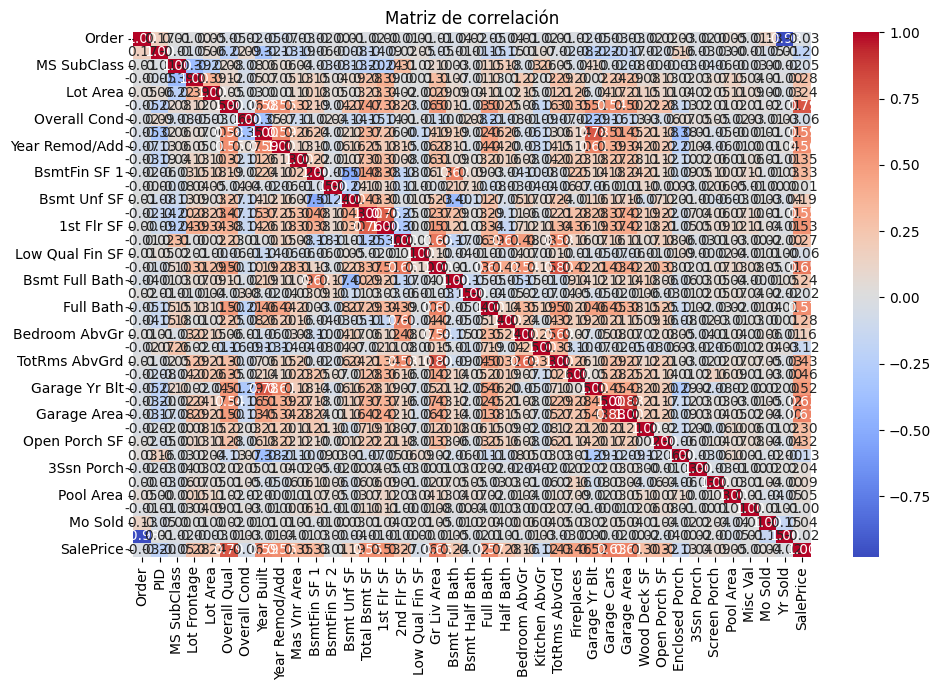

In [15]:
# Correlaciones numéricas
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Limpieza y Preparación
Tratamiento de valores nulos, duplicados y outliers.

In [7]:
print(f'Filas duplicadas: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Imputar nulos en columnas numéricas con mediana
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Columna {col}: imputada con mediana = {median_val:.2f}')

# Imputar nulos en columnas categóricas con moda
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  Columna {col}: imputada con moda = {mode_val}')

print(f'\nValores nulos restantes: {df.isnull().sum().sum()}')
print(f'Shape tras limpieza: {df.shape}')

Filas duplicadas: 0
  Columna Lot Frontage: imputada con mediana = 68.00
  Columna Mas Vnr Area: imputada con mediana = 0.00
  Columna BsmtFin SF 1: imputada con mediana = 370.00
  Columna BsmtFin SF 2: imputada con mediana = 0.00
  Columna Bsmt Unf SF: imputada con mediana = 466.00
  Columna Total Bsmt SF: imputada con mediana = 990.00
  Columna Bsmt Full Bath: imputada con mediana = 0.00
  Columna Bsmt Half Bath: imputada con mediana = 0.00
  Columna Garage Yr Blt: imputada con mediana = 1979.00
  Columna Garage Cars: imputada con mediana = 2.00
  Columna Garage Area: imputada con mediana = 480.00
  Columna Alley: imputada con moda = Grvl
  Columna Mas Vnr Type: imputada con moda = BrkFace
  Columna Bsmt Qual: imputada con moda = TA
  Columna Bsmt Cond: imputada con moda = TA
  Columna Bsmt Exposure: imputada con moda = No
  Columna BsmtFin Type 1: imputada con moda = GLQ
  Columna BsmtFin Type 2: imputada con moda = Unf
  Columna Electrical: imputada con moda = SBrkr
  Columna Firep

/tmp/ipykernel_12130/1578628345.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)
/tmp/ipykernel_12130/1578628345.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [10]:
# Tratamiento de outliers con IQR en la variable objetivo
Q1 = df[TARGET].quantile(0.25)
Q3 = df[TARGET].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
before = df.shape[0]
df = df[(df[TARGET] >= lower) & (df[TARGET] <= upper)]
print(f'Outliers eliminados en {TARGET}: {before - df.shape[0]} filas')
print(f'Shape final: {df.shape}')

Outliers eliminados en SalePrice: 137 filas
Shape final: (2793, 82)


## Transformación y Preprocesamiento
Codificación de variables categóricas y escalado de variables numéricas.

In [12]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_processed = df.copy()

# Codificar columnas categóricas
le = LabelEncoder()
for col in cat_cols:
    if col in df_processed.columns:
        df_processed[col] = le.fit_transform(df_processed[col].astype(str))
        print(f'Columna {col} codificada con LabelEncoder')


# Escalar columnas numéricas (excepto target)
feature_cols = [c for c in df_processed.columns if c != TARGET]
scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print(f'\nPreprocesamiento completado. Shape: {df_processed.shape}')
df_processed.head()

Columna MS Zoning codificada con LabelEncoder
Columna Street codificada con LabelEncoder
Columna Alley codificada con LabelEncoder
Columna Lot Shape codificada con LabelEncoder
Columna Land Contour codificada con LabelEncoder
Columna Utilities codificada con LabelEncoder
Columna Lot Config codificada con LabelEncoder
Columna Land Slope codificada con LabelEncoder
Columna Neighborhood codificada con LabelEncoder
Columna Condition 1 codificada con LabelEncoder
Columna Condition 2 codificada con LabelEncoder
Columna Bldg Type codificada con LabelEncoder
Columna House Style codificada con LabelEncoder
Columna Roof Style codificada con LabelEncoder
Columna Roof Matl codificada con LabelEncoder
Columna Exterior 1st codificada con LabelEncoder
Columna Exterior 2nd codificada con LabelEncoder
Columna Mas Vnr Type codificada con LabelEncoder
Columna Exter Qual codificada con LabelEncoder
Columna Exter Cond codificada con LabelEncoder
Columna Foundation codificada con LabelEncoder
Columna Bsmt Q

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,-1.730953,-1.031412,-0.881179,0.034716,3.532884,3.215348,0.065689,-0.168376,-1.408994,0.305039,...,-0.06041,-0.053671,0.267604,0.051991,-0.091607,-0.443699,1.669069,0.322524,0.227361,215000
1,-1.729773,-1.031152,-0.881179,-1.106004,0.581342,0.259011,0.065689,-0.168376,0.730930,0.305039,...,-0.06041,-0.053671,0.267604,0.051991,-0.091607,-0.074325,1.669069,0.322524,0.227361,105000
2,-1.728593,-1.031147,-0.881179,0.034716,0.629727,0.647114,0.065689,-0.168376,-1.408994,0.305039,...,-0.06041,-0.053671,0.267604,-18.099495,21.465499,-0.074325,1.669069,0.322524,0.227361,172000
3,-1.727413,-1.031136,-0.881179,0.034716,1.210359,0.191221,0.065689,-0.168376,0.730930,0.305039,...,-0.06041,-0.053671,0.267604,0.051991,-0.091607,-0.813073,1.669069,0.322524,0.227361,244000
4,-1.726233,-1.027150,0.046107,0.034716,0.291026,0.582993,0.065689,-0.168376,-1.408994,0.305039,...,-0.06041,-0.053671,0.267604,0.051991,-0.091607,-1.182448,1.669069,0.322524,0.227361,189900


## División Train/Test (80/20)
División estratificada no aplica directamente para regresión; se usa `shuffle=True` con semilla fija para reproducibilidad.

In [13]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

train_df = X_train.copy()
train_df[TARGET] = y_train.values

test_df = X_test.copy()
test_df[TARGET] = y_test.values

print(f'Train: {train_df.shape}')
print(f'Test:  {test_df.shape}')

Train: (2234, 82)
Test:  (559, 82)


## Exportación de train.csv y test.csv
Los archivos se guardan en Google Drive (o directorio local).

In [14]:
train_path = os.path.join(EXPORT_PATH, 'train.csv')
test_path  = os.path.join(EXPORT_PATH, 'test.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f'✅ train.csv guardado en: {train_path}  ({train_df.shape[0]} filas)')
print(f'✅ test.csv  guardado en: {test_path}   ({test_df.shape[0]} filas)')

✅ train.csv guardado en: /content/drive/MyDrive/datasets/housing/train.csv  (2234 filas)
✅ test.csv  guardado en: /content/drive/MyDrive/datasets/housing/test.csv   (559 filas)
